In [1]:
import torch
import torchvision
import cv2
import matplotlib.pyplot as plt
import numpy as np
import imageio
from PIL import Image
from IPython.display import Image as IPImage, display

import importlib.util
import sys
import os

from diffusers.image_processor import VaeImageProcessor
from inference import load_checkpoint_models


/restricted/projectnb/cs599dg/faridkar/.conda/envs/controlnext/lib/python3.10/site-packages/transformers/utils/hub.py:124: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
/restricted/projectnb/cs599dg/faridkar/.conda/envs/controlnext/lib/python3.10/site-packages/diffusers/utils/outputs.py:63: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


In [ ]:

CKPT_DIR = "/restricted/projectnb/cs599dg/faridkar/Pose2Sign/ControlNeXt/ControlNeXt-SVD-v2-Training/outputs/checkpoint-40000"
PRETRAINED_MODEL_PATH = "stabilityai/stable-video-diffusion-img2vid-xt-1-1"

unet, controlnext, image_encoder, vae, feature_extractor = load_checkpoint_models(
        checkpoint_dir=CKPT_DIR,
        pretrained_model_name_or_path=PRETRAINED_MODEL_PATH,
        device="cuda",
        weight_dtype=torch.bfloat16
    )

In [14]:
from IPython.display import Video

pose_video = "/restricted/projectnb/cs599dg/Pose2Sign/ASL_Citizen/test/pose/8336197103293617-CHAMP.mp4"
print(os.path.exists(pose_video))

Video(pose_video, embed=True, width=480, height=360)

True


In [ ]:
def load_video_frames(video_path):
    """
    Load all frames from a video file.

    Args:
        video_path: Path to video file

    Returns:
        List of PIL Image objects in RGB format
    """
    if not os.path.exists(video_path):
        raise FileNotFoundError(f"Video not found: {video_path}")

    frames = []
    cap = cv2.VideoCapture(video_path)

    frame_count = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        # Convert BGR to RGB
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(Image.fromarray(frame))
        frame_count += 1

    cap.release()
    print(f"Loaded {frame_count} frames from {video_path}")

    if frame_count == 0:
        raise ValueError(f"No frames found in video: {video_path}")

    return frames


def video_to_gif(video_path, gif_path="output.gif", frame_skip=1, duration=100, resize=None):
    """
    Convert video to GIF and display in notebook.
    
    Args:
        video_path: Path to input video
        gif_path: Path to save GIF (default: "output.gif")
        frame_skip: Take every Nth frame (default: 1 = all frames)
        duration: Milliseconds per frame (default: 100)
        resize: Tuple (width, height) to resize frames, or None to keep original
    """
    reader = imageio.get_reader(video_path)
    
    frames = []
    for i, frame in enumerate(reader):
        if i % frame_skip == 0:
            img = Image.fromarray(frame)
            if resize:
                img = img.resize(resize, Image.LANCZOS)
            frames.append(img)
    
    frames[0].save(
        gif_path,
        save_all=True,
        append_images=frames[1:],
        duration=duration,
        loop=0
    )
    
    display(IPImage(filename=gif_path))
    return gif_path

# Compare SIMILAR signs (both family members)
similar_sign1 = "513364294341683-MOTHER.mp4"
similar_sign2 = "7154896998335438-FATHER.mp4"

# Compare DIFFERENT signs (unrelated concepts)
different_sign1 = "16027634949398117-WHITE.mp4"
different_sign2 = "946484904568228-FINE.mp4"

base_path = "/restricted/projectnb/cs599dg/Pose2Sign/ASL_Citizen/training"

# Load similar signs
pose_mother = load_video_frames(os.path.join(base_path, "pose", similar_sign1))
pose_father = load_video_frames(os.path.join(base_path, "pose", similar_sign2))

# Load different signs
pose_white = load_video_frames(os.path.join(base_path, "pose", different_sign1))
pose_walk = load_video_frames(os.path.join(base_path, "pose", different_sign2))

print("\n=== Visualizing Similar Signs (MOTHER vs FATHER) ===")
video_to_gif(os.path.join(base_path, "asl", similar_sign1), "mother.gif", frame_skip=2, resize=(256, 256))
video_to_gif(os.path.join(base_path, "asl", similar_sign2), "father.gif", frame_skip=2, resize=(256, 256))

print("\n=== Visualizing Different Signs (WHITE vs WALK) ===")
video_to_gif(os.path.join(base_path, "asl", different_sign1), "white.gif", frame_skip=2, resize=(256, 256))
video_to_gif(os.path.join(base_path, "asl", different_sign2), "walk.gif", frame_skip=2, resize=(256, 256))

Loaded 80 frames from /restricted/projectnb/cs599dg/Pose2Sign/ASL_Citizen/training/pose/513364294341683-MOTHER.mp4
Loaded 112 frames from /restricted/projectnb/cs599dg/Pose2Sign/ASL_Citizen/training/pose/7154896998335438-FATHER.mp4
Loaded 69 frames from /restricted/projectnb/cs599dg/Pose2Sign/ASL_Citizen/training/pose/16027634949398117-WHITE.mp4


FileNotFoundError: Video not found: /restricted/projectnb/cs599dg/Pose2Sign/ASL_Citizen/training/pose/26756336707836725-LIMITED.mp4

In [42]:
vae_scale_factor = 2 ** (len(vae.config.block_out_channels) - 1)
print(f"VAE scale factor: {vae_scale_factor}")
image_processor = VaeImageProcessor(vae_scale_factor=vae_scale_factor)

def process_conditioning_signal(frames):
    condition = image_processor.preprocess(frames, height=224, width=224)
    condition = (condition + 1.0) / 2
    condition = condition.unsqueeze(0)
    condition = condition.to(torch.device("cuda"), dtype=torch.bfloat16)
    print(f"Shape of condition: {condition.shape}") # Should be (1, num_frames, 3, H, W)
    return condition

# Process all four videos
cond_mother = process_conditioning_signal(pose_mother)
cond_father = process_conditioning_signal(pose_father)
cond_white = process_conditioning_signal(pose_white)
cond_walk = process_conditioning_signal(pose_walk)

timestep = torch.tensor([25]).to(torch.device("cuda"))

print("\n=== Extracting ControlNeXt Features ===")
with torch.no_grad():
    feat_mother = controlnext(cond_mother, timestep)['output']
    feat_father = controlnext(cond_father, timestep)['output']
    feat_white = controlnext(cond_white, timestep)['output']
    feat_walk = controlnext(cond_walk, timestep)['output']

print(f"\nMOTHER features: {feat_mother.shape}")
print(f"FATHER features: {feat_father.shape}")
print(f"WHITE features: {feat_white.shape}")
print(f"WALK features: {feat_walk.shape}")

VAE scale factor: 8
Shape of condition: torch.Size([1, 80, 3, 224, 224])
Shape of condition: torch.Size([1, 112, 3, 224, 224])
Shape of condition: torch.Size([1, 69, 3, 224, 224])
Shape of condition: torch.Size([1, 73, 3, 224, 224])

=== Extracting ControlNeXt Features ===

MOTHER features: torch.Size([80, 320, 28, 28])
FATHER features: torch.Size([112, 320, 28, 28])
WHITE features: torch.Size([69, 320, 28, 28])
WALK features: torch.Size([73, 320, 28, 28])


Using 69 frames from each video
Combined shape: (276, 250880)
Applying PCA...


PCA explained variance: 98.83%
Applying t-SNE...


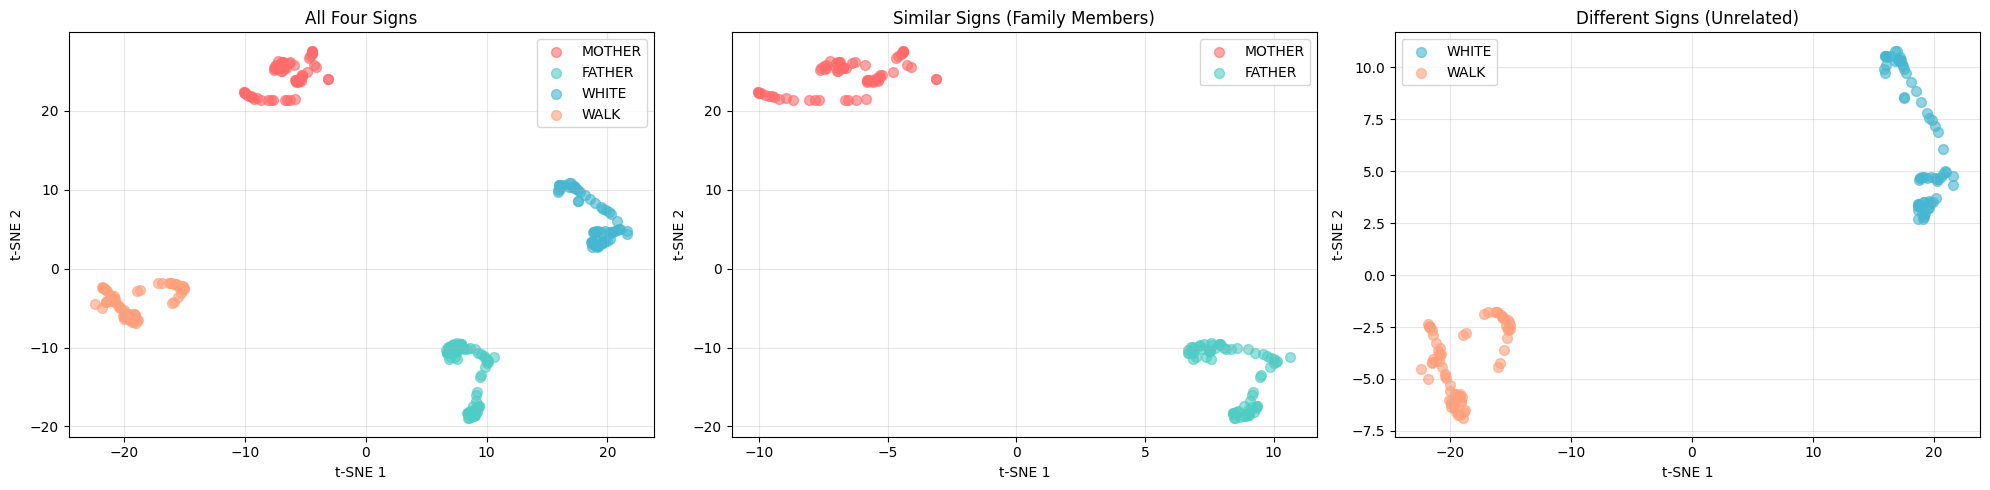


=== Analysis ===
If the control encoder is learning meaningful features:
1. Similar signs (MOTHER/FATHER) should have some overlap
2. Different signs (WHITE/WALK) should be well-separated
3. All four should form distinct clusters in the full plot


In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# Convert all features to numpy
mother_np = feat_mother.float().cpu().numpy()
father_np = feat_father.float().cpu().numpy()
white_np = feat_white.float().cpu().numpy()
walk_np = feat_walk.float().cpu().numpy()

# Find minimum frame count to match dimensions
min_frames = min(len(mother_np), len(father_np), len(white_np), len(walk_np))
print(f"Using {min_frames} frames from each video")

# Truncate all to same length and flatten
mother_flat = mother_np[:min_frames].reshape(min_frames, -1)
father_flat = father_np[:min_frames].reshape(min_frames, -1)
white_flat = white_np[:min_frames].reshape(min_frames, -1)
walk_flat = walk_np[:min_frames].reshape(min_frames, -1)

# Combine all features
combined = np.vstack([mother_flat, father_flat, white_flat, walk_flat])
print(f"Combined shape: {combined.shape}")

# Create labels
labels = np.array([0]*min_frames + [1]*min_frames + [2]*min_frames + [3]*min_frames)
sign_names = ['MOTHER', 'FATHER', 'WHITE', 'WALK']

# Reduce dimensions with PCA first
print("Applying PCA...")
pca = PCA(n_components=50)
combined_pca = pca.fit_transform(combined)
print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.2%}")

# Apply t-SNE
print("Applying t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
data_2d = tsne.fit_transform(combined_pca)

# Create comprehensive visualization
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Plot 1: All four signs
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
for i, (name, color) in enumerate(zip(sign_names, colors)):
    mask = labels == i
    axes[0].scatter(data_2d[mask, 0], data_2d[mask, 1], 
                   c=color, label=name, alpha=0.6, s=50)
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')
axes[0].legend()
axes[0].set_title('All Four Signs')
axes[0].grid(True, alpha=0.3)

# Plot 2: Similar signs (MOTHER vs FATHER)
similar_mask = (labels == 0) | (labels == 1)
for i in [0, 1]:
    mask = labels == i
    axes[1].scatter(data_2d[mask, 0], data_2d[mask, 1], 
                   c=colors[i], label=sign_names[i], alpha=0.6, s=50)
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].legend()
axes[1].set_title('Similar Signs (Family Members)')
axes[1].grid(True, alpha=0.3)

# Plot 3: Different signs (WHITE vs WALK)
for i in [2, 3]:
    mask = labels == i
    axes[2].scatter(data_2d[mask, 0], data_2d[mask, 1], 
                   c=colors[i], label=sign_names[i], alpha=0.6, s=50)
axes[2].set_xlabel('t-SNE 1')
axes[2].set_ylabel('t-SNE 2')
axes[2].legend()
axes[2].set_title('Different Signs (Unrelated)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('feature_clustering_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Analysis ===")
print("If the control encoder is learning meaningful features:")
print("1. Similar signs (MOTHER/FATHER) should have some overlap")
print("2. Different signs (WHITE/WALK) should be well-separated")
print("3. All four should form distinct clusters in the full plot")

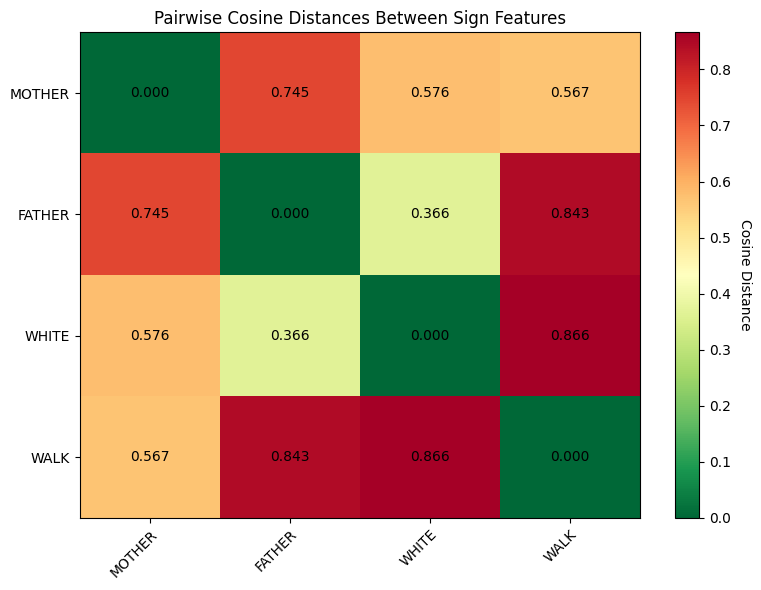


=== Distance Analysis ===
MOTHER-FATHER distance (similar signs): 0.7449
WHITE-WALK distance (different signs): 0.8661
MOTHER-WHITE distance (different): 0.5764
MOTHER-WALK distance (different): 0.5669
FATHER-WHITE distance (different): 0.3659
FATHER-WALK distance (different): 0.8425

=== Expected Behavior ===
If the encoder is learning meaningful pose features:
- Similar signs (MOTHER-FATHER) should have SMALLER distance
- Different signs should have LARGER distances
- Lower values = more similar features


In [44]:
# Quantitative Analysis: Compute pairwise distances between signs
from scipy.spatial.distance import cdist

# Compute mean features for each sign
mean_features = np.array([
    mother_flat.mean(axis=0),
    father_flat.mean(axis=0),
    white_flat.mean(axis=0),
    walk_flat.mean(axis=0)
])

# Compute pairwise cosine distances
from sklearn.metrics.pairwise import cosine_distances
distance_matrix = cosine_distances(mean_features)

# Create heatmap
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(distance_matrix, cmap='RdYlGn_r', aspect='auto')

# Add labels
ax.set_xticks(np.arange(len(sign_names)))
ax.set_yticks(np.arange(len(sign_names)))
ax.set_xticklabels(sign_names)
ax.set_yticklabels(sign_names)

# Rotate the tick labels for better readability
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Cosine Distance', rotation=270, labelpad=15)

# Add text annotations
for i in range(len(sign_names)):
    for j in range(len(sign_names)):
        text = ax.text(j, i, f'{distance_matrix[i, j]:.3f}',
                      ha="center", va="center", color="black", fontsize=10)

ax.set_title('Pairwise Cosine Distances Between Sign Features')
plt.tight_layout()
plt.savefig('distance_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Distance Analysis ===")
print(f"MOTHER-FATHER distance (similar signs): {distance_matrix[0, 1]:.4f}")
print(f"WHITE-WALK distance (different signs): {distance_matrix[2, 3]:.4f}")
print(f"MOTHER-WHITE distance (different): {distance_matrix[0, 2]:.4f}")
print(f"MOTHER-WALK distance (different): {distance_matrix[0, 3]:.4f}")
print(f"FATHER-WHITE distance (different): {distance_matrix[1, 2]:.4f}")
print(f"FATHER-WALK distance (different): {distance_matrix[1, 3]:.4f}")

print("\n=== Expected Behavior ===")
print("If the encoder is learning meaningful pose features:")
print("- Similar signs (MOTHER-FATHER) should have SMALLER distance")
print("- Different signs should have LARGER distances")
print("- Lower values = more similar features")

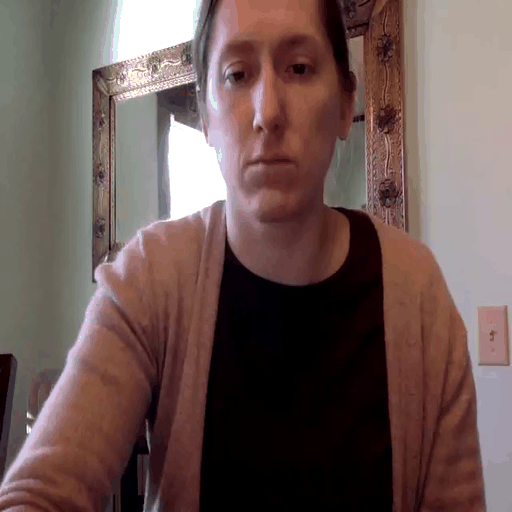

'limited.gif'

In [6]:
path = "/restricted/projectnb/cs599dg/Pose2Sign/ASL_Citizen/validation/asl/026756336707836725-LIMITED.mp4"

video_to_gif(path, "limited.gif", frame_skip=2, resize=(512, 512))

In [ ]:
v